<a href="https://colab.research.google.com/github/roxanamore280-sketch/Pontia_SuperStore/blob/main/Introducci%C3%B3n_al_ML_ejercicio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introducción al Machine Learning

Autor: Carlos Moreno Morera

Revisado por: Javier Moncada Gutiérrez

Última revisión: 05/Apr/2026

## 1.- Regresión lineal con scikit-learn

* En esta sección vamos a resolver un problema de ***Regresión Lineal Simple con la librería de Scikit-Learn***.


* Para resolver el problema de regresión vamos a utilizar la clase **"LinearRegression()"**, cuya documentación esta en el siguiente enlace:<br>
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html


* El ejemplo consiste en predecir cuantas calorías voy a quemar en función de los minutos que voy a estar corriendo. Por ello tenemos un conjunto de datos tomados de forma empírica que nos dan esa relación.


* El objetivo es encontrar los parámetros de la recta que mejor se ajustan a esos datos.

    <span style="font-size:18px">$$calorias = a \cdot tiempo + b$$</span>


* Para resolver este problema vamos a realizar los siguientes pasos:
<span></span><br>
    1. [Carga de datos](#M1)
<span></span><br>
    2. [Cambio de estructura de datos a numpy](#M2)
<span></span><br>
    3. [Visualización de los datos](#M3)
<span></span><br>
    4. [Creacción del modelo (hipótesis) y ajuste](#M4)
<span></span><br>
    5. [Obtención del modelo (hipótesis)](#M5)
<span></span><br>
    6. [Visualización del modelo](#M6)
<span></span><br>
    7. [Medición de la calidad de los resultados](#M7)


<hr>


* En primer lugar vamos a importar las librería necesarias:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model
%matplotlib inline

<hr>


## <a name="M1">1. Carga de datos</a>


* El primer paso que vamos a realizar es el de cargar los datos que los tenemos en los siguientes ficheros:
    - ***DataSet***: "./data/calorias_running/calories_time.csv"
    - ***DataSet Reducido***: "./data/calorias_running/calories_time_reduc.csv"


* Para ello ***leeremos el csv con pandas*** (pasandolo a un dataframe), teniendo las siguientes columnas:
    - Calories
    - Time


In [2]:
df = pd.read_csv("./data/calorias_running/calories_time.csv")
df.sample(5)

FileNotFoundError: [Errno 2] No such file or directory: './data/calorias_running/calories_time.csv'

<hr>


## <a name="M2">2. Cambio de estructura de datos a numpy</a>


* Scikit necesita como entrada para el ajuste (o entrenamiento) del modelo los datos del Dataset de la siguiente forma:
<span></span><br><br>
    - ***Variables de entrada X***: ***Array de Arrays de numpy*** en el que cada array tiene las variables de entrada de un elemento.
<span></span><br><br>
    - ***Variable de salida y*** (solo para aprendizaje supervisado): ***Array de numpy*** en el que cada posición del array contiene la salida o el valor esperado del elemento del Dataset.


* Por tanto, vamos a pasar los datos de las calorias y el tiempo a una nueva estructura de datos para que scikit-learn puedan trabajar con los datos:
<span></span><br><br>
    - La ***columna Tiempo*** que representa la variable independiente 'x', la vamos a pasar a un array de array (***numpy array***)
<span></span><br><br>
    - La ***columna calorias*** que representa la variable dependiente 'y', la vamos a pasar a un ***numpy array***


In [ ]:
X = df['Time'].values
y = df['Calories'].values

# Pasamos la variable independiente (X) de un array a un array de arrays.
X = np.reshape(np.asarray(X), (len(X), 1))

<hr>


## <a name="M3">3. Visualización de los datos</a>


* A continuación pasamos a mostrar visualmente la distribución de los datos que tenemos con una gráfica de dispersión:


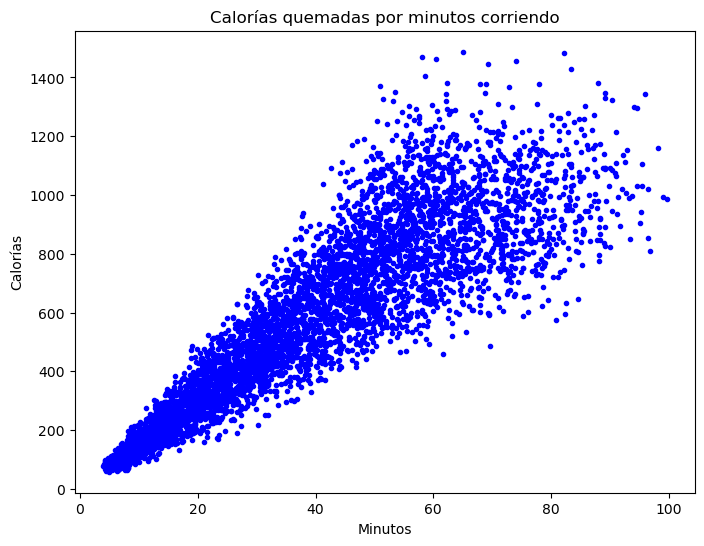

In [ ]:
fig, ax =  plt.subplots(figsize=(8, 6))
ax.scatter(X, y,  color='blue', marker='.', )
ax.set_title("Calorías quemadas por minutos corriendo")
ax.set_xlabel("Minutos")
ax.set_ylabel("Calorías")
plt.show()

<hr>


## <a name="M4">4. Creacción del modelo (hipótesis) y ajuste</a>


* A continuación pasamos a crear un objeto de la clase "***LinearRegression()***" para la resolución del problema de regresión.


* Una vez instanciado, procedemos a ajustar (entrenar) el modelo (o hipótesis) llamando al método ***fit(X,y)*** que recibe como parámetros el conjunto de datos de la variable independiente 'X' y la variable dependiente 'Y'.


* Una vez ajustado (o entrenado) el modelo (o hipótesis), tendremos ajustados los parámetros **'a'** y **'b'** de la recta de regresión de la siguiente manera:

    <span style="font-size:18px">$calorias = a \cdot tiempo + b$</span>

In [ ]:
# Creamos un objeto de la clase LinearRegression
reg = linear_model.LinearRegression()

# Entrenamos el modelo pasandole las variables independientes y dependiente
reg.fit(X, y)

LinearRegression()

<hr>


## <a name="M5">5. Obtención del modelo (hipótesis)</a>


* El objeto de la clase ***LinearRegression*** nos proporciona los resultados de los ajustes de la recta por medio de los atributos de la clase:
<span></span><br><br>
    - ***coef_***: Nos da en una lista los coeficientes de la recta asociados a las variable independientes. En este caso nos da 1 ya que solo tenemos una variable independiente X.
<span></span><br><br>
    - ***intercept_***: Nos devuelve el termino independiente de la recta de regresión; es decir la ***'b'***


In [ ]:
# Obtenemos los coheficientes
a = reg.coef_[0]
b = reg.intercept_

print ("Y = {a:0.2f}X + {b:0.2f}".format(a=a, b=b))
print ("\nCalorias = {a:0.2f} · Tiempo + {b:0.2f}".format(a=a, b=b))

Y = 12.92X + 71.14

Calorias = 12.92 · Tiempo + 71.14


<hr>


## <a name="M6">6. Visualización del modelo</a>


* Para visualizar el modelo vamos a dibujar la recta de regresión aplicando el modelo a los elementos del Dataset.


* Las ***clases de Scikit que implementan la interfaz "Predictors" tienen implementado el método "predict(x)"*** que dadas una variables de entrada (variable independientes en el caso de la regresión), ***devuelve la predicción***; o lo que es lo mismo, el resultado tras aplicar el modelo a cada elemento.

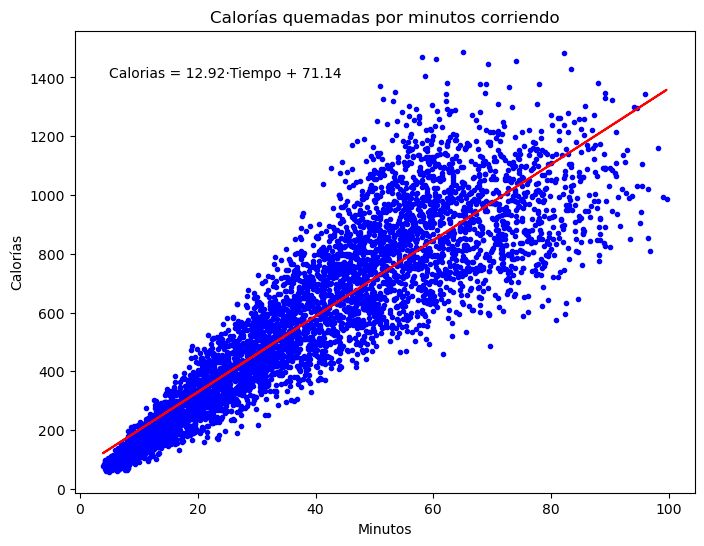

In [ ]:
# Obtenemos las predicciones de los elementos del Dataset con el modelo generado
predicciones = reg.predict(X)

# Pintamos los elementos y la recta de regresión
fig, ax =  plt.subplots(figsize=(8, 6))
ax.scatter(X, y,  color='blue', marker='.', )
ax.plot(X, predicciones, color='red')
ax.set_title("Calorías quemadas por minutos corriendo")
ax.set_xlabel("Minutos")
ax.set_ylabel("Calorías")
ax.text(5, 1400,"Calorias = {a:0.2f}·Tiempo + {b:0.2f}".format(a=a, b=b))
plt.show()

<hr>


## <a name="M7">7. Medición de la calidad de los resultados</a>


* Las ***clases de Scikit que implementan la interfaz "Predictors"*** tienen implementado el método ***"predict(x)"*** para la predicción de nuevos elementos a partir del modelo generado y también implementan otro método que es el método ***score(X,y)*** que devuelve una medida de calidad del modelo generado.


* Para el caso de la Regresión Lineal, el método ***score(X,y)*** devuelve la medida del ***Coeficiente de Determinación R<sup>2</sup>*** que es una medida que nos dice cuanto se ajusta la recta a los datos con los que se ha obtenido la recta, siendo valor '1' un ajuste perfecto y valor '0' un desajuste perfecto.

In [ ]:
r2 = reg.score(X, y)

print ("Coeficiente de determinación R^2: {r2}".format(r2=r2))

Coeficiente de determinación R^2: 0.79589498233559


# 2 - Regresion Lineal Multiple Scikit


* En esta sección vamos a resolver un problema de ***Regresión Lineal Múltiple con la librería de Scikit-Learn***.


* Para resolver el problema de regresión vamos a utilizar la clase **"LinearRegression()"**, cuya documentación esta en el siguiente enlace:<br>
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html


* El ejemplo consiste en predecir cuantas ***calorías quema una persona en función de los minutos que corre, la velocidad a la que corre y su peso corporal***. Por ello tenemos un conjunto de datos tomados de forma empírica que nos dan esa relación.


* El objetivo es encontrar los parámetros $\beta_0, \beta_1, \beta_2, \beta_3$ que mejor se ajustan a esos datos.

<span style="font-size:18px">$$Calorias = \beta_0 + \beta_1 \cdot Tiempo + \beta_2 \cdot Velocidad + \beta_3 \cdot Peso$$</span>


* Para resolver este problema vamos a realizar los siguientes pasos:
<span></span><br>
    1. [Carga de datos](#M1)
<span></span><br>
    2. [Cambio de estructura de datos a numpy](#M2)
<span></span><br>
    3. [Visualización de los datos](#M3)
<span></span><br>
    4. [Creacción del modelo (hipótesis) y ajuste](#M4)
<span></span><br>
    5. [Obtención del modelo (hipótesis)](#M5)
<span></span><br>
    6. [Medición de la calidad de los resultados](#M6)


<hr>


* En primer lugar vamos a importar las librería necesarias:

<hr>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import linear_model
%matplotlib inline

<hr>


## <a name="M1">1. Carga de datos</a>


* El primer paso que vamos a realizar es el de cargar los datos que los tenemos en el siguiente fichero:
    - ***DataSet***: "./data/calorias_running/calories_time_weight_speed.csv"


* Para ello ***leeremos el csv con pandas*** (pasandolo a un dataframe), teniendo las siguientes columnas:
    - Calorias
    - Tiempo
    - Peso
    - Velocidad

In [ ]:
df = pd.read_csv("./data/calorias_running/calories_time_weight_speed.csv")
df.sample(5)

,Calorias,Tiempo,Peso,Velocidad
109,1221.2,59.6,78.8,15.1
2819,339.9,14.7,86.4,15.5
2200,539.8,41.0,70.9,10.8
3437,826.5,46.6,74.1,13.9
3126,380.8,36.9,58.3,10.3


<hr>


## <a name="M2">2. Cambio de estructura de datos a numpy</a>


* Scikit necesita como entrada para el ajuste (o entrenamiento) del modelo los datos del Dataset de la siguiente forma:
<span></span><br><br>
    - ***Variables de entrada X***: ***Array de Arrays de numpy*** en el que cada array tiene las variables de entrada de un elemento.
<span></span><br><br>
    - ***Variable de salida y*** (solo para aprendizaje supervisado): ***Array de numpy*** en el que cada posición del array contiene la salida o el valor esperado del elemento del Dataset.


* Por tanto, vamos a pasar los datos de las calorias y el tiempo a una nueva estructura de datos para que scikit-learn puedan trabajar con los datos:
<span></span><br><br>
    - Las ***columnas Tiempo, Peso y Velocidad*** representan las variables independientes 'x<sub>n</sub>' y las vamos a pasar a un array de array (***numpy array***)
<span></span><br><br>
    - La ***columna calorias*** que representa la variable dependiente 'y', la vamos a pasar a un ***numpy array***


In [ ]:
X = df[['Tiempo', 'Velocidad', 'Peso']].values
y = df['Calorias'].values

<hr>


## <a name="M3">3. Visualización de los datos</a>


* A continuación pasamos a mostrar visualmente las relaciones entre cada par de variables del dataset:

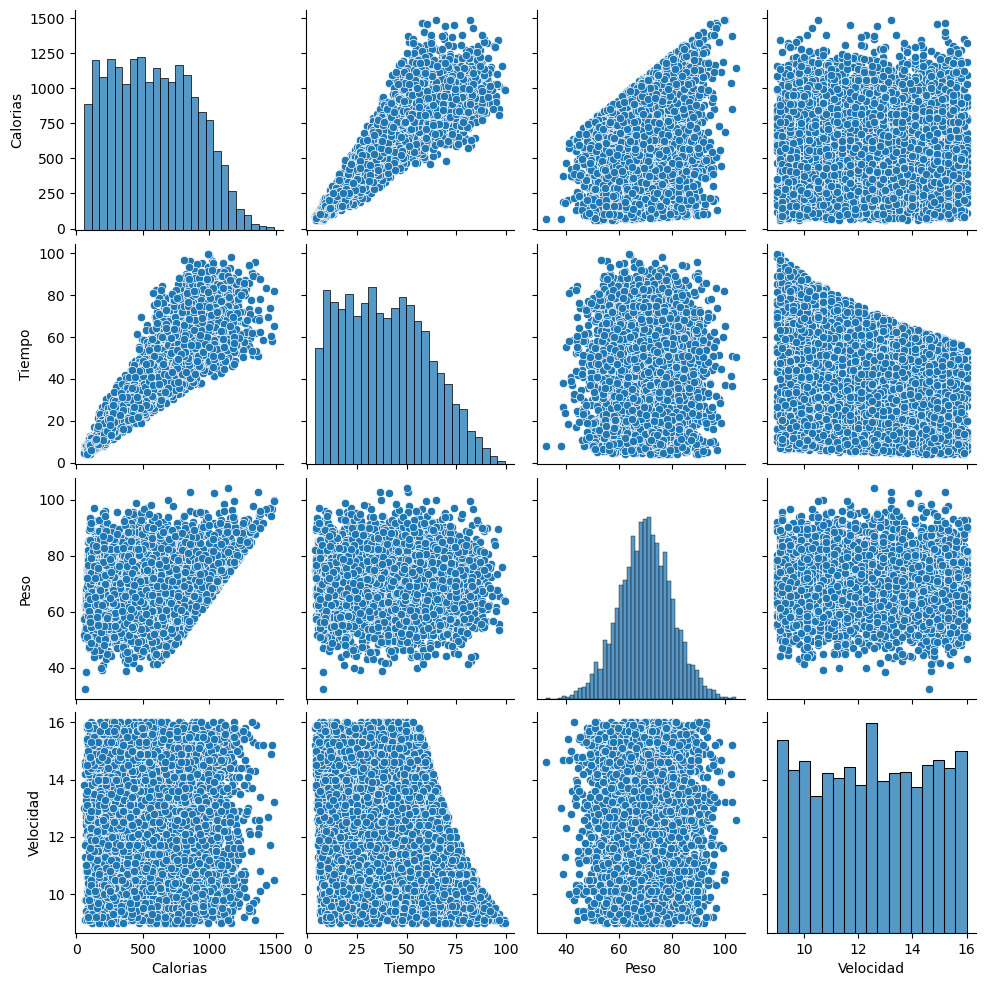

In [ ]:
sns.pairplot(df)

<hr>


## <a name="M4">4. Creacción del modelo (hipótesis) y ajuste</a>


* A continuación pasamos a crear un objeto de la clase "***LinearRegression()***" para la resolución del problema de regresión.


* Una vez instanciado, procedemos a ajustar (entrenar) el modelo (o hipótesis) llamando al método ***fit(X,y)*** que recibe como parámetros el conjunto de datos de las variables independientes 'X' y la variable dependiente 'Y'.


* Una vez ajustado (o entrenado) el modelo (o hipótesis), tendremos ajustados los parámetros ***$\beta_n$*** de la siguiente manera:

<span style="font-size:18px">$$Calorias = \beta_0 + \beta_1 \cdot Tiempo + \beta_3 \cdot Velocidad + \beta_3 \cdot Peso$$</span>

In [ ]:
# Creamos un objeto de la clase LinearRegression
reg_mul = linear_model.LinearRegression()

# Entrenamos el modelo pasandole las variables independientes y dependiente
reg_mul.fit(X, y)

LinearRegression()

<hr>


## <a name="M5">5. Obtención del modelo (hipótesis)</a>


* El objeto de la clase ***LinearRegression*** nos proporciona los resultados de los ajustes de la regresión por medio de los atributos de la clase:
<span></span><br><br>
    - ***coef_***: Nos da en una lista los coeficientes de la recta asociados a las variable independientes. En este caso nos da 3 ya que tenemos 3 variables independientes X.
<span></span><br><br>
    - ***intercept_***: Nos devuelve el termino independiente; es decir la ***$\beta_0$***

In [ ]:
# Obtenemos los coheficientes
betas = reg_mul.coef_
beta_0 = reg_mul.intercept_

print ("Y = {b0:0.2f} + {b1:0.2f}X1 + {b2:0.2f}X2 + {b3:0.2f}X3"
       .format(b0=beta_0, b1=betas[0], b2=betas[1], b3=betas[2]))
print ("\nCalorias = {b0:0.2f} + {b1:0.2f}·Tiempo + {b2:0.2f}·Velocidad + {b3:0.2f}·Peso"
       .format(b0=beta_0, b1=betas[0], b2=betas[1], b3=betas[2]))

Y = -1164.85 + 14.26X1 + 46.66X2 + 8.55X3

Calorias = -1164.85 + 14.26·Tiempo + 46.66·Velocidad + 8.55·Peso


<hr>


## <a name="M6">6. Medición de la calidad de los resultados</a>


* Las ***clases de Scikit que implementan la interfaz "Predictors"*** tienen implementado el método **"predict(x)"** para la predicción de nuevos elementos a partir del modelo generado y también implementan otro método que es el método ***score(X,y)*** que devuelve una medida de calidad del modelo generado.


* Para el caso de la Regresión Lineal, el método ***score(X,y)*** devuelve la medida del ***Coeficiente de Determinación R<sup>2</sup>*** que es una medida que nos dice cuanto se ajusta la recta a los datos con los que se ha obtenido la recta, siendo valor '1' un ajuste perfecto y valor '0' un desajuste perfecto.

In [ ]:
r2 = reg_mul.score(X, y)

print ("Coeficiente de determinación R^2: {r2}".format(r2=r2))

Coeficiente de determinación R^2: 0.9539022259261689


# 3 - Hold Out: Regresion Lineal Multiple


* El objetivo de esta sección es el de resolver un problema de regresión con unos ***datos de entrenamiento*** y **testear el modelo o hipótesis obtenido con los datos de test.**


* Para ello, dado un Dataset, vamos a particionar los datos con la técnica de particionado ***Hold Out*** y vamos a:

    1. Entrenar el modelo con los datos de Entrenamiento
    2. Evaluar el modelo con los datos de Entrenamiento
    3. Evaluar el modelo con los datos de Test
    4. Conclusiones: Comparativa de las evaluaciones del modelo con los datos de Entrenamiento y Test


* El ejemplo que vamos a realizar consiste en predecir cuantas calorías voy a quemar en función de los minutos que voy a estar corriendo, la velocidad media a la que corro y mi peso. Por ello tenemos un conjunto de datos tomados de forma empírica que nos dan esa relación. Por tanto el objetivo es encontrar los parámetros de la recta que mejor se ajustan a esos datos.


* El ejemplo que vamos a realizar, consiste en predecir cuantas ***calorías quema una persona en función de los minutos que corre, la velocidad a la que corre y su peso corporal***. Por ello tenemos un conjunto de datos tomados de forma empírica que nos dan esa relación.


* El objetivo es encontrar los parámetros $\beta_0, \beta_1, \beta_2, \beta_3$ que ***mejor se ajustan a los datos de entrenamiento***.

<span style="font-size:18px">$$Calorias = \beta_0 + \beta_1 \cdot Tiempo + \beta_3 \cdot Velocidad + \beta_3 \cdot Peso$$</span>


* Para ello vamos a realizar los siguientes pasos:

    1. Carga de Datos
    2. Cambio de estructura de datos a numpy
    3. Particionado de datos en Entrenamiento y Test
    4. Generación del modelo con los datos de Entrenamiento
    5. Evaluación del modelo con los datos de Entrenamiento
    6. Evaluación del modelo con los datos de Test
    7. Conclusiones: Comparativa de resultados

<hr>


* En primer lugar importemos las librerías necesarias:

In [ ]:
import numpy as np
import pandas as pd
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

<hr>


## 1. Carga de Datos


* El primer paso que vamos a realizar es el de cargar los datos que los tenemos en los siguientes ficheros:
    - ***DataSet***: "./data/calorias_running/calories_time_weight_speed.csv"


* Para ello ***leeremos el csv con pandas*** (pasandolo a un dataframe), teniendo las siguientes columnas:
    - Calorias
    - Tiempo
    - Peso
    - Velocidad

In [ ]:
df = pd.read_csv("./data/calorias_running/calories_time_weight_speed.csv")
df.sample(5)

,Calorias,Tiempo,Peso,Velocidad
2949,110.7,6.5,73.8,13.3
3346,651.0,48.0,72.0,10.9
2031,505.3,45.6,61.6,10.4
4944,550.7,47.8,51.2,13.0
533,383.8,22.7,62.0,15.8


<hr>


## 2. Cambio de estructura de datos a numpy


* Vamos a pasar los datos de las calorias y el tiempo a una nueva estructura de datos para que scikit-learn puedan trabajar con los datos:
<span></span><br><br>
    - Las ***columna Tiempo, Peso y Velocidad*** representan las variables independientes 'x<sub>n</sub>' y las vamos a pasar a un array de array (***numpy array***)
<span></span><br><br>
    - La ***columna calorias*** que representa la variable dependiente 'y', la vamos a pasar a un ***numpy array***

In [ ]:
X = df[['Tiempo', 'Velocidad', 'Peso']].values
y = df['Calorias'].values

<hr>


## 3. Particionado de datos en Entrenamiento y Test


* En este punto vamos a dividir el dataset en un conjunto de datos de entrenamiento y datos de test.


* Para ello vamos a llamar a la función ***train_test_split()*** y dividimos los datos en entrenamiento y test. Para este ejemplo vamos a coger un ***20% de datos de test y un 80% de datos de entrenamiento.***


In [ ]:
np.random.seed(2)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

<hr>


## 4. Generación del modelo con los datos de Entrenamiento

* A continuación pasamos a crear un objeto de la clase "***LinearRegression()***" para la resolución del problema de regresión.


* Una vez instanciado, procedemos a ajustar (entrenar) el modelo (o hipótesis) llamando al método ***fit(X,y)*** que recibe como parámetros el conjunto de datos de entrenamiento de las variables independientes 'X' y la variable dependiente 'Y'.


* Una vez ajustado (o entrenado) el modelo (o hipótesis), tendremos ajustados los parámetros ***$\beta_n$*** de la siguiente manera:

<span style="font-size:16px">$$Calorias = \beta_0 + \beta_1 \cdot Tiempo + \beta_3 \cdot Velocidad + \beta_3 \cdot Peso$$</span>


In [ ]:
# Creamos un objeto de la clase LinearRegression
reg_mul = linear_model.LinearRegression()

# Entrenamos el modelo pasandole las variables independientes y dependiente
reg_mul.fit(X_train, y_train)

LinearRegression()

<hr>


## 5. Evaluación del modelo con los datos de Entrenamiento


* Llegados a este punto podemos medir el ***error que comete el modelo***, en este caso con los datos de entrenamiento, que son datos que se han utilizado para generar el modelo (o hipótesis).


* Para ello vamos a utilizar 2 medidas de ***Accuracy***:

    1. ***MAE***: Mean Absolute Error (Error Absoluto Medio)
    2. ***MSE***: Mean Squared Error (Error Cuadrático Medio)
    
    
* Para calcular esta medidas, necesitamos tener el valor real de la salida y la predicción del modelo.


* Para obtener la predicción del modelo, utilizamos el método ***.predict(X)*** pasándole los datos a predecir y obteniendo el resultado.


In [ ]:
# Obtenemos las predicciones del modelo con los datos de entrenamiento
y_predict = reg_mul.predict(X_train)

# Calculamos los errores
mae_train = mean_absolute_error(y_true=y_train, y_pred=y_predict)
mse_train = mean_squared_error(y_true=y_train, y_pred=y_predict)

print("Error Absoluto Medio (MAE): {error}".format(error=mae_train))
print("Error Cuadrático Medio (MSE): {error}".format(error=mse_train))

Error Absoluto Medio (MAE): 48.143486667833855
Error Cuadrático Medio (MSE): 4425.892283745692


<hr>


## 6. Evaluación del modelo con los datos de Test


* Vamos a realizar los mismos pasos que en el punto anterior, pero en este caso vamos a ver el error cometido con los datos de test.


* Para ello necesitamos predecir cual es la salida del modelo con los datos de test y esto lo hacemos llamando al método ***.predict(X)***.


* Con las predicciones y los resultados reales calculamos los errores:

In [ ]:
# Obtenemos las predicciones del modelo con los datos de test
y_predict = reg_mul.predict(X_test)

# Calculamos los errores
mae_test = mean_absolute_error(y_true=y_test, y_pred=y_predict)
mse_test = mean_squared_error(y_true=y_test, y_pred=y_predict)

print("Error Absoluto Medio (MAE): {error}".format(error=mae_test))
print("Error Cuadrático Medio (MSE): {error}".format(error=mse_test))

Error Absoluto Medio (MAE): 48.443056890796726
Error Cuadrático Medio (MSE): 4508.549637473967


<hr>


## 7. Conclusiones: Comparativa de resultados


* Podemos observar que los errores cometidos con los datos de entrenamiento y test son muy similares.


* El ***error absoluto medio*** nos dice el ***error medio que cometemos en la predicción de las calorias quemadas***; es decir, que al hacer las predicciones nos equivocamos de media en 48 calorias.


* Si nos fijamos ***el MAE es practicamente igual*** evaluándolo tanto ***con los datos de entrenamiento como con los de test***, lo que significa que el modelo generado es un ***modelo muy estable*** que generaliza bastante bien.


* ***Si los errores cometidos con los datos de entrenamiento y test fuesen muy dispares podria significar que***:

    - Tenemos pocos datos de los que aprender.
    - Hay mucha varianza en los datos.
    - Estamos particionando mal los datos en entrenamiento y test (mucho sesgo en cada partición)
    - Estamos entrenando mall nuestro modelo
    - Etc.

# 4 - Cross Validation: Regresion Lineal Multiple


* El objetivo de esta sección es el de ***resolver un problema de regresión generando 'N' modelos entrenados con 'N' conjuntos de entrenamiento distintos y evaluados con 'N' conjuntos de test distintos***, particionando los datos con la técnica de ***Cross Validation***.


* Para ello, dado un Dataset, vamos a particionar 'N' veces los datos con la técnica de particionado ***Cross Validation*** y generar 'N' Modelos, viendo los errores cometidos por estos modelos con los diferentes conjuntos de datos.


* El ejemplo que vamos a realizar consiste en predecir cuantas calorías voy a quemar en función de los minutos que voy a estar corriendo, la velocidad media a la que corro y mi peso. Por ello tenemos un conjunto de datos tomados de forma empírica que nos dan esa relación. Por tanto el objetivo es encontrar los parámetros de la recta que mejor se ajustan a esos datos.


* El ejemplo que vamos a realizar, consiste en predecir cuantas ***calorías quema una persona en función de los minutos que corre, la velocidad a la que corre y su peso corporal***. Por ello tenemos un conjunto de datos tomados de forma empírica que nos dan esa relación.


* El objetivo es encontrar los parámetros $\beta_0, \beta_1, \beta_2, \beta_3$ que ***mejor se ajustan a los datos de entrenamiento***.

<span style="font-size:16px">$$Calorias = \beta_0 + \beta_1 \cdot Tiempo + \beta_3 \cdot Velocidad + \beta_3 \cdot Peso$$</span>


* Para ello vamos a realizar los siguientes pasos:

    1. Carga de Datos
    2. Cambio de estructura de datos a numpy
    3. 'N' Particionados de datos en Entrenamiento y Test
    4. Generación y evaluación de los 'N' modelos con MAE
    5. Conclusiones: Comparativa de resultados

<hr>


* En primer lugar importemos las librerías necesarias:


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn import linear_model
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error

<hr>


## 1. Carga de Datos


* El primer paso que vamos a realizar es el de cargar los datos que los tenemos en los siguientes ficheros:
    - ***DataSet***: "./data/calorias_running/calories_time_weight_speed.csv"


* Para ello ***leeremos el csv con pandas*** (pasandolo a un dataframe), teniendo las siguientes columnas:
    - Calorias
    - Tiempo
    - Peso
    - Velocidad

In [ ]:
df = pd.read_csv("./data/calorias_running/calories_time_weight_speed.csv")
df.describe()

,Calorias,Tiempo,Peso,Velocidad
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,579.695640,39.364560,70.101200,12.503720
std,310.379773,21.433103,9.982623,2.038588
min,58.500000,3.900000,32.500000,9.000000
25%,313.775000,21.200000,63.500000,10.700000
50%,565.350000,38.000000,70.100000,12.500000
75%,820.100000,55.200000,76.800000,14.300000
max,1487.600000,99.600000,104.100000,16.000000


<hr>


## 2. Cambio de estructura de datos a numpy


* Vamos a pasar los datos de las calorias y el tiempo a una nueva estructura de datos para que scikit-learn puedan trabajar con los datos:
<span></span><br><br>
    - Las ***columna Tiempo, Peso y Velocidad*** representan las variables independientes 'x<sub>n</sub>' y las vamos a pasar a un array de array (***numpy array***)
<span></span><br><br>
    - La ***columna calorias*** que representa la variable dependiente 'y', la vamos a pasar a un ***numpy array***

In [ ]:
X = df[['Tiempo', 'Velocidad', 'Peso']].values
y = df['Calorias'].values

<hr>


## 3. 'N' Particionados de datos en Entrenamiento y Test


* En este punto vamos a dividir el dataset en 'N' conjuntos de datos.


* En cada una de las 'N' iteracciones, un conjunto de datos sera conjunto de datos de test y el resto de conjuntos serán datos de entrenamiento.


* En Scikit utilizamos la clase ***KFold(n_splits)*** para dividir el Dataset en ***'N'*** (n_splits) conjuntos.


* En este caso no vamos a obtener unos arrays con los datos de entrenamiento y test; si no, los ***índices de los elementos del Dataset que en cada paso actuarán como entrenamiento y como test***.


* Para el ejemplo que vamos a realizar vamos a dividir el dataset en 10 conjuntos de datos:

In [ ]:
k_fold = KFold(n_splits=10)

<hr>


## 4. Generación y evaluación de los 'N' modelos con MAE


* Vamos a generar tantos modelos como particiones hayamos realizado y vamos a evaluarlos con los datos de entrenamiento y test:

In [ ]:
l_mae_train = []
l_mae_test = []

for train, test in k_fold.split(X, y):

    # Creo un nuevo objeto de la clase LinearRegression
    reg_mul = linear_model.LinearRegression()

    # Ajusto el modelo
    reg_mul.fit(X[train], y[train])

    # Imprimo el modelo
    print ("\nCalorias = {b0:0.2f} + {b1:0.2f} Tiempo + {b2:0.2f} Velocidad + {b3:0.2f} Peso"
       .format(b0=reg_mul.intercept_, b1=reg_mul.coef_[0], b2=reg_mul.coef_[1], b3=reg_mul.coef_[2]))

    # Prediccion
    y_train_predict = reg_mul.predict(X[train])
    y_test_predict = reg_mul.predict(X[test])

    # Errores
    mae_train = mean_absolute_error(y_true=y[train], y_pred=y_train_predict)
    mae_test = mean_absolute_error(y_true=y[test], y_pred=y_test_predict)
    print("TRAIN - MAE: {error:0.2f}".format(error=mae_train))
    print("TEST - MAE: {error:0.2f}".format(error=mae_test))

    # Guardamos los errores
    l_mae_train.append(mae_train)
    l_mae_test.append(mae_test)


Calorias = -1157.95 + 14.24 Tiempo + 46.27 Velocidad + 8.54 Peso
TRAIN - MAE: 48.65
TEST - MAE: 43.96

Calorias = -1173.56 + 14.27 Tiempo + 46.96 Velocidad + 8.62 Peso
TRAIN - MAE: 48.75
TEST - MAE: 43.89

Calorias = -1161.30 + 14.27 Tiempo + 46.44 Velocidad + 8.54 Peso
TRAIN - MAE: 48.06
TEST - MAE: 49.39

Calorias = -1165.42 + 14.29 Tiempo + 46.66 Velocidad + 8.55 Peso
TRAIN - MAE: 47.81
TEST - MAE: 51.33

Calorias = -1165.95 + 14.25 Tiempo + 46.61 Velocidad + 8.59 Peso
TRAIN - MAE: 48.16
TEST - MAE: 48.45

Calorias = -1163.89 + 14.26 Tiempo + 46.68 Velocidad + 8.54 Peso
TRAIN - MAE: 47.66
TEST - MAE: 52.66

Calorias = -1163.89 + 14.27 Tiempo + 46.66 Velocidad + 8.54 Peso
TRAIN - MAE: 48.02
TEST - MAE: 49.48

Calorias = -1155.83 + 14.25 Tiempo + 46.57 Velocidad + 8.45 Peso
TRAIN - MAE: 48.29
TEST - MAE: 47.12

Calorias = -1173.11 + 14.26 Tiempo + 46.96 Velocidad + 8.61 Peso
TRAIN - MAE: 48.36
TEST - MAE: 47.65

Calorias = -1167.63 + 14.26 Tiempo + 46.79 Velocidad + 8.56 Peso
TRAIN -

<hr>


## 5. Conclusiones: Comparativa de resultados


* En la siguiente gráfica podemos observar en cada generación del modelo con diferentes conjuntos de entrenamiento y test lo siguiente:
<span></span><br><br>
    - El error comentido con el modelo generado en cada iteración con los conjuntos de entrenamiento es más o menos similar, con lo que el algoritmo de aprendizaje genera un modelo muy robusto.
<span></span><br><br>    
    - El error cometido con los datos de test es más variable (lo cual es normal), incluso en ocasiones se comete menos error con los datos de test que con los de entrenamiento.
<span></span><br><br>    
    - Los errores de los modelos tanto con los datos de test como de entrenamiento son muy similares entre sí, con lo que podemos concluir que el algoritmo de aprendizaje con los datos disponibles, genera un modelo muy robusto que geneeraliza bastante bien.

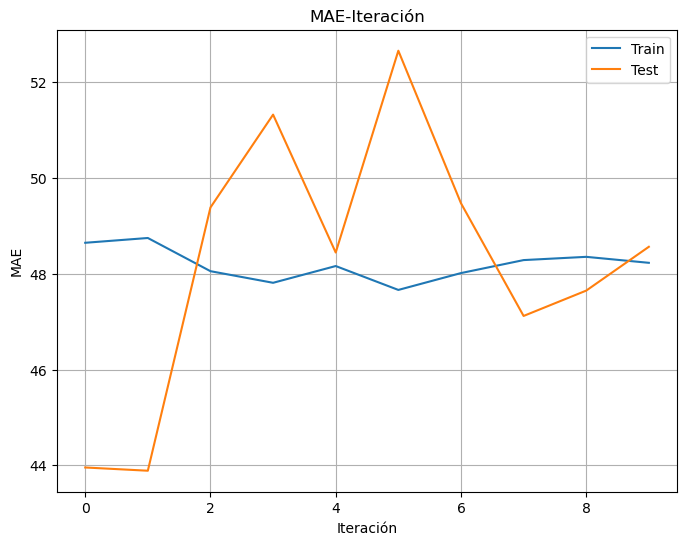

In [ ]:
fig, ax =  plt.subplots(figsize=(8, 6))
ax.plot([index for index, value in enumerate(l_mae_train)], [mae for mae in l_mae_train])
ax.plot([index for index, value in enumerate(l_mae_test)], [mae for mae in l_mae_test])
ax.set_title("MAE-Iteración")
ax.set_xlabel("Iteración")
ax.set_ylabel("MAE")
ax.grid(True)
plt.gca().legend(('Train','Test'))
plt.show()

# 5 - Clasificación Múltiple:  Regresión Logística con Scikit-Learn


* En esta sección vamos a resolver un problema de ***Clasificación Múltiple con las Regresión Logística usando la librería de Scikit-Learn*** para el caso en el que tengamos en nuestro Dataset ***más de dos Features (o atributos)***.


* Para resolver el problema de Clasificación vamos a utilizar la clase **"LogisticRegression()"**, cuya documentación esta en el siguiente enlace:<br>
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html


* El ejemplo con el que vamos a trabajar, consiste en ***clasificar tres tipos de flores, conociendo los tamaños (alto y ancho) del petalo y sépalo*** de la flor; es decir, que tendremos 4 atributos (o Features).


* Al ser un problema ***de Clasificación múltiple obtenemos tantos modelos como clases tengamos que clasificar***, por lo que para esta caso tendremos que encontrar los parámetros $\beta_0, \beta_1, \beta_2, \beta_3, \beta_4$ para ***tres funciones de decisión*** que sean capaces de discernir una clase con el resto:
<span></span><br><br>
<span style="font-size:16px">$$Flor\;1 = \beta^{1}_0 + \beta^{1}_1 \cdot SepalLenght + \beta^{1}_2 \cdot SepalWith + \beta^{1}_3 \cdot PetalLenght + \beta^{1}_4 \cdot PetalWith$$</span>
<span></span><br><br>
<span style="font-size:16px">$$Flor\;2 = \beta^{2}_0 + \beta^{2}_1 \cdot SepalLenght + \beta^{2}_2 \cdot SepalWith + \beta^{2}_3 \cdot PetalLenght + \beta^{2}_4 \cdot PetalWith$$</span>
<span></span><br><br>
<span style="font-size:16px">$$Flor\;3 = \beta^{3}_0 + \beta^{3}_1 \cdot SepalLenght + \beta^{3}_2 \cdot SepalWith + \beta^{3}_3 \cdot PetalLenght + \beta^{3}_4 \cdot PetalWith$$</span>
    
    
* Aplicando estas funciones de decisión a una logística podremos saber la probabilidad de pertenencia de cada flor a cada una de las clases de la siguiente manera:
<span></span><br><br>
<span style="font-size:16px">$$P(Y=Flor\;1|SepalLenght,SepalWith,PetalLenght,PetalWith) = \frac{1}{1 + e^{-(\beta^{1}_0 + \beta^{1}_1 \cdot SepalLenght + \beta^{1}_2 \cdot SepalWith + \beta^{1}_3 \cdot PetalLenght + \beta^{1}_4 \cdot PetalWith)}}$$</span>
<span></span><br><br>
<span style="font-size:16px">$$P(Y=Flor\;2|SepalLenght,SepalWith,PetalLenght,PetalWith) = \frac{1}{1 + e^{-(\beta^{2}_0 + \beta^{2}_1 \cdot SepalLenght + \beta^{2}_2 \cdot SepalWith + \beta^{2}_3 \cdot PetalLenght + \beta^{2}_4 \cdot PetalWith)}}$$</span>
<span></span><br><br>
<span style="font-size:16px">$$P(Y=Flor\;3|SepalLenght,SepalWith,PetalLenght,PetalWith) = \frac{1}{1 + e^{-(\beta^{3}_0 + \beta^{3}_1 \cdot SepalLenght + \beta^{3}_2 \cdot SepalWith + \beta^{3}_3 \cdot PetalLenght + \beta^{3}_4 \cdot PetalWith)}}$$</span>
    

* ***Daremos como predicción para una nueva flor, aquella clase que mayor probabilidad dé***.


* Para resolver este problema vamos a realizar los siguientes pasos:
<span></span><br>
    1. [Carga de datos](#M1)
<span></span><br>
    2. [Cambio de estructura de datos a numpy y transformación de las etiquetas a números](#M2)
<span></span><br>
    3. [Visualización de los datos](#M3)
<span></span><br>
    4. [Creacción del modelo (hipótesis) y ajuste](#M4)
<span></span><br>
    5. [Obtención del modelo (hipótesis)](#M5)
<span></span><br>
    6. [Cálculo de predicción](#M6)


* En primer lugar vamos a importar las librería necesarias:

<hr>



In [ ]:
import warnings
warnings.filterwarnings("ignore")

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn import preprocessing
%matplotlib inline

<hr>


## <a name="M1">1. Carga de datos</a>


* El primer paso que vamos a realizar es el de cargar los datos que los tenemos en el siguiente fichero:
    - ***DataSet***: "./data/iris/iris.csv"


* Para ello ***leeremos el csv con pandas*** (pasandolo a un dataframe), teniendo las siguientes columnas:
    - ***class***: Clase de la flor (Iris-versicolor, Iris-setosa)
    - ***sepal_length***: El "largo" del Sepalo
    - ***sepal_width***: El "ancho" del Sepalo
    - ***petal_length***: El "largo" del Pétalo
    - ***petal_width***: El "ancho" del Pétalo
    


In [ ]:
df = pd.read_csv("./data/iris/iris.csv")
df.sample(5)

,sepal_length,sepal_width,petal_length,petal_width,class
7,5.0,3.4,1.5,0.2,Iris-setosa
39,5.1,3.4,1.5,0.2,Iris-setosa
38,4.4,3.0,1.3,0.2,Iris-setosa
83,6.0,2.7,5.1,1.6,Iris-versicolor
105,7.6,3.0,6.6,2.1,Iris-virginica


<hr>


## <a name="M2">2. Cambio de estructura de datos a numpy y transformación de las etiquetas a números</a>


* Scikit necesita como entrada para el ajuste (o entrenamiento) del modelo los datos del Dataset de la siguiente forma:
<span></span><br><br>
    - ***Variables de entrada X***: ***Array de Arrays de numpy*** en el que cada array tiene las variables de entrada de un elemento.
<span></span><br><br>
    - ***Variable de salida y*** (solo para aprendizaje supervisado): ***Array de numpy*** en el que cada posición del array contiene la salida o el valor esperado del elemento del Dataset.


* Por tanto, vamos a pasar los datos las flores a una nueva estructura de datos para que scikit-learn puedan trabajar con los datos:
<span></span><br><br>
    - Las ***columnas sepal_length y sepal_width*** representan las variables de entrada y las vamos a pasar a un array de array (***numpy array***).
<span></span><br><br>
    - La ***columna class*** que representa la clase (o variable de salida) y la vamos a pasar a un ***numpy array***.
    
    
* Por otro lado tenemos que transformar la clase de la flor a números, por lo que utilizaremos la clase ***LabelEncoder()*** para transformar las etiquetas de las clases a números, siendo esta transformación:

    - ***0***: ***Iris-Setosa***
    - ***1***: ***Iris-Versicolor***
    - ***2***: ***Iris-Virginica***

In [ ]:
from sklearn import preprocessing

X = df[['sepal_length', 'sepal_width',
        'petal_length', 'petal_width']].values   # Obtengo el alto y ancho del sepalo
y_labels = df['class'].values                    # Obtengo las etiquetas


le = preprocessing.LabelEncoder()     # Instancio un objeto de la clase LabelEncoder()
y = le.fit_transform(y_labels)        # Transformo las etiquetas a números

<hr>


## <a name="M3">3. Visualización de los datos</a>


* A continuación vamos a ver la relación que hay entre cada par de atributos de los tres tipos de flores.

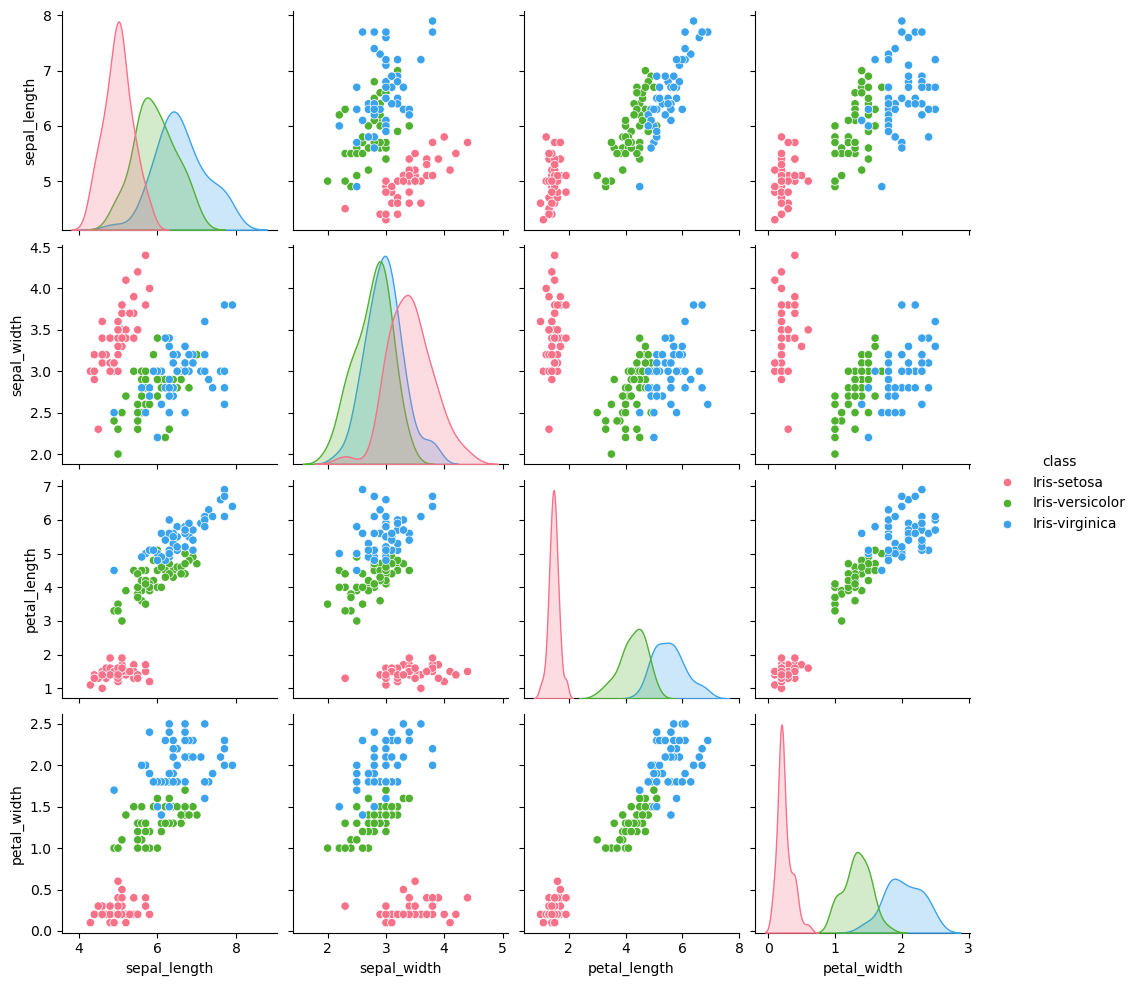

In [ ]:
sns.pairplot(df, hue="class", palette="husl")

<hr>


## <a name="M4">4. Creacción del modelo (hipótesis) y ajuste</a>


* A continuación pasamos a crear un objeto de la clase "***LogisticRegression()***" para la resolución del problema de clasificación.


* Una vez instanciado, procedemos a ajustar (entrenar) el modelo (o hipótesis) llamando al método ***fit(X,y)*** que recibe como parámetros el conjunto de datos de las variables de entrada 'X' y la variable de salida 'Y'.

In [ ]:
# Creamos un objeto de la clase LogisticRegression pasandole una serie de parámetros
logreg = LogisticRegression(solver='liblinear', multi_class='ovr', max_iter=50)

# Entrenamos el modelo siendo la 'X' el tamaño del sepalo e 'y' el tipo de flor
logreg.fit(X, y)

LogisticRegression(max_iter=50, multi_class='ovr', solver='liblinear')

<hr>


## <a name="M5">5. Obtención del modelo (hipótesis)</a>


* El objeto de la clase ***LogisticRegression*** nos proporciona los resultados de los parámetros $\beta_n$ por medio de los atributos de la clase:
<span></span><br><br>
    - ***coef_***: Nos devuelve en una matriz los parámetros del $\beta_1$ al $\beta_n$ para cada una de las funciones de decisión.
<span></span><br><br>
    - ***intercept_***: Nos devuelve una lista con los parámetros ***$\beta_0$*** para cada una de las funciones de decisión.
    

* Obteniendo estos valores podemos obtener el modelo generado:

In [ ]:
b0 = logreg.intercept_
b = logreg.coef_


print("\nIris-setosa: Z = {b0:0.2f} + {b1:0.2f} · sepal_length + {b2:0.2f} · sepal_width + {b3:0.2f} · petal_length + {b4:0.2f} · petal_width"
      .format(b0=b0[0], b1=b[0,0], b2=b[0,1], b3=b[0,2], b4=b[0,3]))

print("\nIris-versicolor: Z = {b0:0.2f} + {b1:0.2f} · sepal_length + {b2:0.2f} · sepal_width + {b3:0.2f} · petal_length + {b4:0.2f} · petal_width"
      .format(b0=b0[1], b1=b[1,0], b2=b[1,1], b3=b[1,2], b4=b[1,3]))

print("\nIris-virginica: Z = {b0:0.2f} + {b1:0.2f} · sepal_length + {b2:0.2f} · sepal_width + {b3:0.2f} · petal_length + {b4:0.2f} · petal_width"
      .format(b0=b0[2], b1=b[2,0], b2=b[2,1], b3=b[2,2], b4=b[2,3]))


Iris-setosa: Z = 0.27 + 0.41 · sepal_length + 1.46 · sepal_width + -2.26 · petal_length + -1.03 · petal_width

Iris-versicolor: Z = 1.09 + 0.42 · sepal_length + -1.60 · sepal_width + 0.58 · petal_length + -1.39 · petal_width

Iris-virginica: Z = -1.21 + -1.71 · sepal_length + -1.53 · sepal_width + 2.47 · petal_length + 2.56 · petal_width


<hr>


## <a name="M6">6. Cálculo de Predicción</a>


* A continuación vamos a ver como predecir la clase de una Flor usando la librería de Scikit con el método ".predict(flor)" y como obtener esa misma predicción aplicando del modelo obtenido.


* Para ello seleccionemos una flor del Dataset, que para este ejemplo vamos a seleccionar la flor:
    - Class: Iris-Setosa
    - Sepal_lenght: 4.9
    - Sepal_With: 3.0
    - Petal_lenght: 1.4
    - Petal_With: 0.2


In [ ]:
X_flor = X[1]
y_flor = y[1]

print('Flor: X={} - y={} - Clase = {}'.format(X_flor, y_flor, le.inverse_transform([y_flor])))

Flor: X=[4.9 3.  1.4 0.2] - y=0 - Clase = ['Iris-setosa']


* A continuación vamos a ver cual es la predicción que nos devuelve Scikit-Learn.


* Vamos también cuales son los parámetros de la función de decisión y cual es el resultado de esa función de decisión para cada clase:

In [ ]:
prediccion = logreg.predict([X_flor])
fun_decision = logreg.decision_function([X_flor])

print('Predicción -> Pertenece a la clase {}'.format(prediccion))
print('Predicción Etiquetada -> Pertenece a la clase {}'.format(le.inverse_transform(prediccion)))
print('Resultado de la función de decisión: ' + \
      '\n\tIris-Setosa: {:0.2f}\n\tIris-Versicolor: {:0.2f}\n\tIris-Virginica: {:0.2f}' \
     .format(fun_decision[0,0], fun_decision[0,1], fun_decision[0,2]))

Predicción -> Pertenece a la clase [0]
Predicción Etiquetada -> Pertenece a la clase ['Iris-setosa']
Resultado de la función de decisión: 
	Iris-Setosa: 3.31
	Iris-Versicolor: -1.14
	Iris-Virginica: -10.21


* A continuación vamos a calcular la función de decisión de esa flor para cada clase usando el modelo y posteriormente la probabilidad de pertenencia a cada clase:

In [ ]:
# Obtenemos los parámetros
b0 = logreg.intercept_
b = logreg.coef_

# Función de decisión
z_setosa =     b0[0] + (b[0,0] * X_flor[0]) + (b[0,1] * X_flor[1]) + (b[0,2] * X_flor[2]) + (b[0,3] * X_flor[3])
z_versicolor = b0[1] + (b[1,0] * X_flor[0]) + (b[1,1] * X_flor[1]) + (b[1,2] * X_flor[2]) + (b[1,3] * X_flor[3])
z_virginica =  b0[2] + (b[2,0] * X_flor[0]) + (b[2,1] * X_flor[1]) + (b[2,2] * X_flor[2]) + (b[2,3] * X_flor[3])

# Imprimimos las funciones de decisión
print('Función de decisión: ' + \
      '\n\tIris-Setosa: {:0.2f}\n\tIris-Versicolor: {:0.2f}\n\tIris-Virginica: {:0.2f}' \
     .format(z_setosa, z_versicolor, z_virginica))

# Calculamos las probabilidades
prob_setosa =     1 / (1 + math.exp(-1 * (z_setosa)))
prob_versicolor = 1 / (1 + math.exp(-1 * (z_versicolor)))
prob_virginica =  1 / (1 + math.exp(-1 * (z_virginica)))

# Imprimimos las probabilidades
print('\nProbabilidad de pertenencia a cada clase: ' + \
      '\n\tIris-Setosa: {:0.2f}\n\tIris-Versicolor: {:0.2f}\n\tIris-Virginica: {:0.2f}' \
     .format(prob_setosa, prob_versicolor, prob_virginica))

Función de decisión: 
	Iris-Setosa: 3.31
	Iris-Versicolor: -1.14
	Iris-Virginica: -10.21

Probabilidad de pertenencia a cada clase: 
	Iris-Setosa: 0.96
	Iris-Versicolor: 0.24
	Iris-Virginica: 0.00


* Veamos como realizamos esos cálculos con detalle:

In [ ]:
# Imprimimos por pantalla la información de cada cálculo
print('\nIris-Setosa ')
print('  Z =  {:0.2f} + {:0.2f}·{:0.2f} + {:0.2f}·{:0.2f} + {:0.2f}·{:0.2f} + {:0.2f}·{:0.2f} = {:0.2f}'.
      format(b0[0], b[0,0], X_flor[0], b[0,1], X_flor[1], b[0,2], X_flor[3], b[0,3], X_flor[3], z_setosa))
print('  g(Z) =  1 / 1 + e^-({:0.2f}) = {:0.2f}'.format(z_setosa, 1 / (1 + math.exp(-1 * z_setosa))))


print('\nIris-Versicolor ')
print('  Z =  {:0.2f} + {:0.2f}·{:0.2f} + {:0.2f}·{:0.2f} + {:0.2f}·{:0.2f} + {:0.2f}·{:0.2f} = {:0.2f}'.
      format(b0[1], b[1,0], X_flor[0], b[1,1], X_flor[1], b[1,2], X_flor[2], b[1,3], X_flor[3], z_versicolor))
print('  g(Z) =  1 / 1 + e^-({:0.2f}) = {:0.2f}'.format(z_versicolor, 1 / (1 + math.exp(-1 * z_versicolor))))


print('\nIris-Virginica ')
print('  Z =  {:0.2f} + {:0.2f}·{:0.2f} + {:0.2f}·{:0.2f} + {:0.2f}·{:0.2f} + {:0.2f}·{:0.2f} = {:0.2f}'.
      format(b0[2], b[2,0], X_flor[0], b[2,1], X_flor[1], b[2,2], X_flor[2], b[2,3], X_flor[3], z_virginica))
print('  g(Z) =  1 / 1 + e^-({:0.2f}) = {:0.2f}'.format(z_virginica, 1 / (1 + math.exp(-1 * z_virginica))))


Iris-Setosa 
  Z =  0.27 + 0.41·4.90 + 1.46·3.00 + -2.26·0.20 + -1.03·0.20 = 3.31
  g(Z) =  1 / 1 + e^-(3.31) = 0.96

Iris-Versicolor 
  Z =  1.09 + 0.42·4.90 + -1.60·3.00 + 0.58·1.40 + -1.39·0.20 = -1.14
  g(Z) =  1 / 1 + e^-(-1.14) = 0.24

Iris-Virginica 
  Z =  -1.21 + -1.71·4.90 + -1.53·3.00 + 2.47·1.40 + 2.56·0.20 = -10.21
  g(Z) =  1 / 1 + e^-(-10.21) = 0.00


# 6 - Transformaciones de Datos de Variables Categóricas


* En esta sección vamos a ver como ***transformar los datos de variable categóricas para que los algorítmos de aprendizaje*** (que solo entienden de "números" y no de Strings) ***puedan usar esos datos*** para generar los modelos.


* Vamos a ver las siguientes Transformaciones:
<span></span><br>
    1. [Codificación Binaria](#M1)
<span></span><br>
    2. [Codificación One Hot Encode](#M2)
<span></span><br>
    3. [Label Encoder](#M3)


* Los típos de variables estadísticas que nos podemos encontrar son las siguientes:


<img src="./data/tipos_variables.png" style="width: 800px;"/>



* ***Los algorítmos de aprendizaje no tienen ningún problema a la hora de trabajar con variables cuantitativas ya que estas siendo discretas (por ejemplo: 1, 2, 3, ... N) o continuas ($-\infty$ a $\infty$)*** pueden trabajar con ellas.


* Sin embargo las ***variables Cualitativas o Categorias (por ejemplo {Madrid, Barcelona, Valencia}, {Primera, Segunda, Tercera}) son Strings y los algoritmos de aprendizaje no pueden trabajar con ellas por tanto hay que transformarlas a números***.


* Distinguimos dos tipos de variables Cualitativas o Categóricas que son:
<span></span><br><br>
    + ***Nominales***: No admiten orden, por ejemplo {Hombre, Mujer} o {Madrid, Barcelona, Valencia}
<span></span><br><br>
    + ***Ordinales***: Admiten un orden entre ellas como por ejemplo {Primera, Segunda, Tercera}


* Dependiendo del tipo de variables Cualitativas o Categóricas debemos de realizar una transformación un otra.


* ***Variables Nominales***: Debemos de codificar la salida de tal manera que podamos distiguir los tipos. Esto lo podemos hacer con una codificación binária en caso de tener 2 valores o con un "One Hot Encode" en caso de tener más valores. Veamos unos ejemplos:

    * ***Codificación Binaria***:
    
|Genero|Codificación|
|---|---|
|Masculino|0|
|Femenino|1|

   * ***Codificación One Hot Encode***:
   
|Ciudad|Madrid|Barcelona|Valencia|
|---|---|---|---|
|Madrid|1|0|0|
|Barcelona|0|1|0|
|Valencia|0|0|1|


* ***Variables Ordinales***: Al ser unas variables que admiten orden, podemos transformar los String a variables numéricas, poniendo el orden que queramos definir. Esta transformación se conoce como "Label Encode". Veamos un ejemplo:

    * ***Codificación Label Encode***:
    
|Categoria|Cat_Ordenada_1|Cat_Ordenada_2|
|---|---|---|
|Primera|1|3|
|Segunda|2|2|
|Tercera|3|1|


* Veamos a continuación como hacer este tipo de Transformaciones:



<hr>

## Carga de Datos

* En primer lugar vamos a definir un DataFrame de ejemplo con el que poder ver estas transformaciones.


* El siguiente DataFrame tiene las siguientes variables que las clasificaremos como:

    + ***Edad***: Variable Continua
    + ***Genero***: Variable Categorica Nominal (2 valores)
    + ***Ciudad_embarque***:Variable Categorica Nominal (>2 valores)
    + ***Clase***: Variable Categorica Ordinal



In [ ]:
import pandas as pd

df = pd.DataFrame(data={
    'edad': [20, 30, 40, 50, 60],
    'genero': ['Mas', 'Mas', 'Fem', 'Fem', 'Fem'],
    'ciudad_embarque': ['Cherboarg', 'Queenstown', 'Southampton', 'Cherboarg', 'Queenstown'],
    'clase': ['Cuarta', 'Tercera', 'Primera', 'Segunda', 'Segunda']
})

df

,edad,genero,ciudad_embarque,clase
0,20,Mas,Cherboarg,Cuarta
1,30,Mas,Queenstown,Tercera
2,40,Fem,Southampton,Primera
3,50,Fem,Cherboarg,Segunda
4,60,Fem,Queenstown,Segunda


<hr>


# <a name="M1">1. Codificación Binaria</a>


* Vamos a transformar la variable genero a una variable binaria.


* Esto lo podemos hacer con la clase **"LabelBinarizer()"** de scikit-learn de la siguiente manera:

In [ ]:
from sklearn.preprocessing import LabelBinarizer

lb = LabelBinarizer()
df['genero_binario'] = lb.fit_transform(df['genero'])
df[['genero', 'genero_binario']]

,genero,genero_binario
0,Mas,1
1,Mas,1
2,Fem,0
3,Fem,0
4,Fem,0


<hr>


# <a name="M2">2. Codificación One Hot Encode</a>


* Vamos a transformar la variable "ciudad_embarque" en tantas nuevas variables como elementos tenga.


* Esto lo podemos hacer con la clase **"OneHotEncoder()"** de scikit-learn de la siguiente manera:

In [ ]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder()
x = df[['ciudad_embarque']].values
x_one_hot = ohe.fit_transform(x).toarray()
x_one_hot

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.]])

* Como vemos nos devuelve una matriz con las codificaciones de cada una de las filas del DataFrame (transformadas a un numpy array).


* Vamos ahora a pasar estas nuevas variables al DataFrame:


In [ ]:
df_one_hot = pd.DataFrame(x_one_hot, columns = ["ciudad_embarque_"+str(int(i)) for i in range(x_one_hot.shape[1])])
df_all = pd.concat([df, df_one_hot], axis=1)
df_all

,edad,genero,ciudad_embarque,clase,genero_binario,ciudad_embarque_0,ciudad_embarque_1,ciudad_embarque_2
0,20,Mas,Cherboarg,Cuarta,1,1.0,0.0,0.0
1,30,Mas,Queenstown,Tercera,1,0.0,1.0,0.0
2,40,Fem,Southampton,Primera,0,0.0,0.0,1.0
3,50,Fem,Cherboarg,Segunda,0,1.0,0.0,0.0
4,60,Fem,Queenstown,Segunda,0,0.0,1.0,0.0


### Codificación One Hot Encode en Pandas


* Esta transformación también nos la permite hacer la librería de Pandas de la siguiente manera:

In [ ]:
df_dummy = pd.get_dummies(df['ciudad_embarque'], dtype=int)
df_dummy

,Cherboarg,Queenstown,Southampton
0,1,0,0
1,0,1,0
2,0,0,1
3,1,0,0
4,0,1,0


* Concatenamos la codificación resultante al DataFrame

In [ ]:
df = pd.concat([df, df_dummy], axis=1)
df

,edad,genero,ciudad_embarque,clase,genero_binario,Cherboarg,Queenstown,Southampton
0,20,Mas,Cherboarg,Cuarta,1,1,0,0
1,30,Mas,Queenstown,Tercera,1,0,1,0
2,40,Fem,Southampton,Primera,0,0,0,1
3,50,Fem,Cherboarg,Segunda,0,1,0,0
4,60,Fem,Queenstown,Segunda,0,0,1,0


<hr>



# <a name="M3">3. Label Encoder</a>


* Vamos a transformar la variable "clase" a una variable numerica.


* Esto lo podemos hacer con la clase **"LabelEncoder()"** de scikit-learn de la siguiente manera:

In [ ]:
from sklearn.preprocessing import LabelEncoder

df['clase_endoce'] = LabelEncoder().fit_transform(df['clase'])
df[['clase', 'clase_endoce']]

,clase,clase_endoce
0,Cuarta,0
1,Tercera,3
2,Primera,1
3,Segunda,2
4,Segunda,2


* Con la clase **"LabelEncoder()"** de Scikit tenemos el problema de que nos pone a cada elemento un valor en función del orden alfabetico.


* En el caso de trabajar con variables categóricas ordinales, nos interesa darle un sentido ordinal a los valores de la variable, por lo que vamos a asignarle los valores de la siguiente manera:

In [ ]:
df['clase_endoce'] = df['clase'].apply(lambda x: 1 if x == 'Primera'
                                       else (2 if x == 'Segunda'
                                             else (3 if x == 'Tercera' else 4)))
df['clase_encode'] = df['clase'].apply(lambda x: {'Primera':1, 'Segunda':2, 'Tercera':3, 'Cuarta':4}[x])
df[['clase', 'clase_endoce']]

,clase,clase_endoce
0,Cuarta,4
1,Tercera,3
2,Primera,1
3,Segunda,2
4,Segunda,2


<hr>


# Resultado Final:


* Tras realizar todas estas transformaciones ya tendríamos el Dataset transformado correctamente para que pueda ser utilizado por un Algoritmo de Aprendizaje:


In [ ]:
df[['edad', 'genero_binario', 'Cherboarg', 'Queenstown', 'Southampton', 'clase_endoce']]

,edad,genero_binario,Cherboarg,Queenstown,Southampton,clase_endoce
0,20,1,1,0,0,4
1,30,1,0,1,0,3
2,40,0,0,0,1,1
3,50,0,1,0,0,2
4,60,0,0,1,0,2


# 7 - Normalizacion de Datos


* En esta sección vamos a ver como ***Normalizar las variables*** de un Dataset.


* ***La Normalización es un proceso que consiste en convertir el rango de valores de una variable numérica, a un rango estandar como por ejemplo entre [-1,1], [0,1], etc.***


* Una de las maneras más comunes para normalizar los datos sería la siguiente conocida como el **"Min Max Scaler"**:
<span></span><br><br>
<span style="font-size:20px">$$\overline{X}^{(i)} = \frac{x^{(i)} - min^{(i)}}{max^{(i)} - min^{(i)}}$$</span>
    
    
* Donde $min^{(j)}$ y $max^{(j)}$ son respectivamente, el valor mínimo y máximo de la variable $j$ en el conjunto de datos.


* ***¿Por qué es bueno normalizar?*** - No es necesario normalizar los datos, pero en la práctica la normalización de los datos permite a los Algoritmos de Aprendizaje generar un modelo más rápido. Por ejemplo cuando hacemos uso del gradiente descendente para la obtención de un modelo, este lo hacemos actualizando unos parámetros (los parámetros $\beta_n$) y lo hacemos utilizando derivadas parciales del error cuadrático medio con respecto a los parámetros ($\beta_n$). Si $x^{(1)}$ se encuentra en un rando de valores de [0, 10000] y $x^{(2)}$ se encuentra en un rando de [0,5], hace que la derivada con respecto a la característica más grande domine la actualización.


<hr>


## Carga de Datos


* Veamos a continuación un ejemplo de normalización, utilizando el siguiente DataFrame:

In [ ]:
from sklearn.preprocessing import MinMaxScaler

import pandas as pd

df_origin = pd.DataFrame(data={'X1': [0.0, 1.0,    2.0,    3.0,    4.0,    5.0],
                               'X2': [0.0, 10.0,   20.0,   30.0,   40.0,   50.0],
                               'X3': [0.0, 100.0,  200.0,  300.0,  400.0,  500.0],
                               'X4': [0.0, 1000.0, 2000.0, 3000.0, 4000.0, 5000.0],
                               'y' : [0.0, 4.0,    8.0,    12.0,   16.0,   20.0]
                              })

df_origin

,X1,X2,X3,X4,y
0,0.0,0.0,0.0,0.0,0.0
1,1.0,10.0,100.0,1000.0,4.0
2,2.0,20.0,200.0,2000.0,8.0
3,3.0,30.0,300.0,3000.0,12.0
4,4.0,40.0,400.0,4000.0,16.0
5,5.0,50.0,500.0,5000.0,20.0


<hr>


# Normalización: Min Max Scaler

* Para normalizar los datos, lo podemos hacer con la clase **"MinMaxScaler()"** de scikit-learn de la siguiente manera, obteniendo el nuevo DataFrame Normalizado

In [ ]:
from sklearn.preprocessing import MinMaxScaler

df_norm = df_origin.copy()

min_max_scaler = MinMaxScaler()

df_norm[['X1','X2','X3','X4']] = min_max_scaler.fit_transform(df_norm[['X1','X2','X3','X4']].values)
df_norm

,X1,X2,X3,X4,y
0,0.0,0.0,0.0,0.0,0.0
1,0.2,0.2,0.2,0.2,4.0
2,0.4,0.4,0.4,0.4,8.0
3,0.6,0.6,0.6,0.6,12.0
4,0.8,0.8,0.8,0.8,16.0
5,1.0,1.0,1.0,1.0,20.0


<hr>


# Ejemplo: Regresión Lineal


* Vamos a ver a continuación un ejemplo de como resolver un problema de Regresión lineal con los datos normalizados y sin normalizar:


### 1. Cargamos los datos

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("./data/calorias_running/calories_time_weight_speed.csv")
df.sample(5)

,Calorias,Tiempo,Peso,Velocidad
3457,623.0,78.4,50.3,9.1
538,546.4,43.0,78.5,9.4
4845,88.8,4.5,76.5,15.0
1241,277.7,15.3,66.6,15.7
1183,701.9,38.6,71.8,14.7


### 2. Normalizamos los datos:

In [ ]:
from sklearn.preprocessing import MinMaxScaler

df_calorias_norm = df.copy()
min_max_scaler = MinMaxScaler()
df_calorias_norm[['Tiempo', 'Peso', 'Velocidad']] = min_max_scaler.fit_transform(df[['Tiempo', 'Peso', 'Velocidad']].values)
df_calorias_norm.sample(5)

,Calorias,Tiempo,Peso,Velocidad
560,587.7,0.438871,0.604749,0.114286
4299,816.5,0.529781,0.370112,0.814286
4114,1042.6,0.771160,0.670391,0.085714
856,300.4,0.200627,0.509777,0.271429
3742,94.0,0.047022,0.251397,0.542857


### 3. Generamos los modelos

* Vamos a generar dos Modelos, uno con los datos noralizados y otro con los datos sin normalizar:

In [ ]:
from sklearn import linear_model

# Creamos un objeto de la clase LinearRegression
reg_original = linear_model.LinearRegression()
reg_normalizado = linear_model.LinearRegression()

X_orginal = df[['Tiempo', 'Peso', 'Velocidad']].values
y_orginal = df['Calorias'].values
X_normalizado = df_calorias_norm[['Tiempo', 'Peso', 'Velocidad']].values
y_normalizado = df_calorias_norm['Calorias'].values

# Entrenamos el modelo pasandole las variables independientes y dependiente
reg_original.fit(X_orginal, y_orginal)
reg_normalizado.fit(X_normalizado, y_normalizado)

# Obtenemos los modelos
betas_original = reg_original.coef_
beta_0_original = reg_original.intercept_
betas_normalizado = reg_normalizado.coef_
beta_0_normalizado = reg_normalizado.intercept_

### 4. Imprimimos los modelos

* Vamos a imprimir los dos modelos que como podemos observar son diferentes, pero aplicando los datos bien normalizalizados o no (dependiendo del modelo) vamos a obtener la predicción:


In [ ]:
# Imprimimos los modelos
print("Modelo Sin Datos Normalizados:"\
      "\nCalorias = {b0:0.2f} + {b1:0.2f}·Tiempo + {b2:0.2f}·Velocidad + {b3:0.2f}·Peso"
      .format(b0=beta_0_original, b1=betas_original[0], b2=betas_original[1], b3=betas_original[2]))

print("\nModelo Con Datos Normalizados:"\
      "\nCalorias = {b0:0.2f} + {b1:0.2f}·Tiempo + {b2:0.2f}·Velocidad + {b3:0.2f}·Peso"
      .format(b0=beta_0_normalizado, b1=betas_normalizado[0], b2=betas_normalizado[1], b3=betas_normalizado[2]))

Modelo Sin Datos Normalizados:
Calorias = -1164.85 + 14.26·Tiempo + 8.55·Velocidad + 46.66·Peso

Modelo Con Datos Normalizados:
Calorias = -411.26 + 1364.95·Tiempo + 612.49·Velocidad + 326.62·Peso


### 5. Transformación de Parámetros


* Si transformamos los parámetros del modelo normalizado usando la "desnormalización", podemos ver como obtenemos unos parámetros del modelo parecidos a los del modelo sin normalizar:

In [ ]:
betas_transformadas = min_max_scaler.transform([betas_normalizado])
betas_transformadas

array([[14.22199795,  8.10039003, 45.37477962]])

# 8 - Correlación de Datos


* En este Notebook vamos a ver como obtener los ***valores de correlación entre variables***.


* Dadas dos variables de un Dataset $(a_1,b_1), (a_2,b_2), ..., (a_n,b_n)$ se define el coeficiente de correlación lineal entre A y B como $r_{ab}$, siendo esta una ***medida de dependencia lineal entre las dos variable A y B.***


* La correlación entre dos variables ***puede tomar valores entre [-1,1]*** indicando los valores más cercanos a ***-1 y 1 que las variables tienen una depencia lineal muy alta*** y con valores ***cercanos a 0, una dependencia lineal muy baja***.


* El objetivo de ver la correlación entre variables para la resolución de problemas de aprendizaje es el de ***eliminar las variables que estan altamente correladas entre sí*** (o son similares entre sí) con el objetivo de no pasar al Algoritmo de Aprendizaje ***variables que no le sean útiles al modelo generado para discernir o tomar decisiones***.


* Con la eliminación de variables muy correladas (si las hubiese) conseguimos reducir el número de variables del Dataset a utilizar por el algoritmo de aprendizaje lo que significa que:
    + ***Reduciremos los tiempos de computo*** al tener que trabajar con menos datos
    + ***Reduciremos el "ruido" en los datos*** ya que dos variables similares entre sí no ayuda a los algoritmos de aprendizaje a aprender y puede generar peores modelos.

<hr>


* Veamos a continuación un ejemplo de como calcular la correlación entre variables y como eliminar las que estan correladas entre sí:


## 1. Cargamos los datos


* Vamos a cargar el dataset de calorias.


* Para hacer el ejemplo un poco más didáctico, vamos a crearnos una nueva columna llamada 'Peso_gramos' que tendremos el valor de los elementos de la columna 'Peso' en gramos; es decir, el mismo valor multiplicado por 1000:

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("./data/calorias_running/calories_time_weight_speed.csv")
df['Peso_gramos'] = df['Peso'].apply(lambda x: x * 1000)
df.sample(5)

,Calorias,Tiempo,Peso,Velocidad,Peso_gramos
4352,336.0,19.8,77.0,12.7,77000.0
2007,664.2,73.9,46.2,11.3,46200.0
649,552.3,53.2,65.5,9.2,65500.0
4944,550.7,47.8,51.2,13.0,51200.0
1027,803.6,49.6,73.5,12.8,73500.0


<hr>


## 2. Correlación entre variables

* Con la funcion de pandas ***.corr()***, nos devuelve la matriz de correlaciones entre cada par de variables:

In [ ]:
df_corr = df.corr()
df_corr

,Calorias,Tiempo,Peso,Velocidad,Peso_gramos
Calorias,1.000000,0.892129,0.263631,0.008829,0.263631
Tiempo,0.892129,1.000000,-0.006131,-0.297225,-0.006131
Peso,0.263631,-0.006131,1.000000,-0.017812,1.000000
Velocidad,0.008829,-0.297225,-0.017812,1.000000,-0.017812
Peso_gramos,0.263631,-0.006131,1.000000,-0.017812,1.000000


* Los valores cercanos a 1 y -1 nos indican que son variables muy correladas entre sí y cuanto más cercano sea el valor a 0 nos indican que no están muy correladas.


* Como nos interesa saber el grado de correlación, podemos pasar esos valores a su valor absoluto.


* De la matriz de correlaciones solo nos interesa la matriz triangular superior o la inferior que es donde tenemos las correlaciones entre cada para de variables.


* Para ello vamos a quedarnos con el valor absoluto de la matriz triangular superior para ver las relaciones entre cada par de variables:

In [ ]:
df_corr = df.corr().abs()
df_upper = df_corr.where(np.triu(np.ones(df_corr.shape), k=1).astype(bool))
df_upper

,Calorias,Tiempo,Peso,Velocidad,Peso_gramos
Calorias,NaN,0.892129,0.263631,0.008829,0.263631
Tiempo,NaN,NaN,0.006131,0.297225,0.006131
Peso,NaN,NaN,NaN,0.017812,1.000000
Velocidad,NaN,NaN,NaN,NaN,0.017812
Peso_gramos,NaN,NaN,NaN,NaN,NaN
